In [1]:
import sys
sys.path.append('..')

import src as src
import numpy as np
import matplotlib.pyplot as plt
import scipy

# H-alpha case, redshift 1.5

0.6563
0.6563


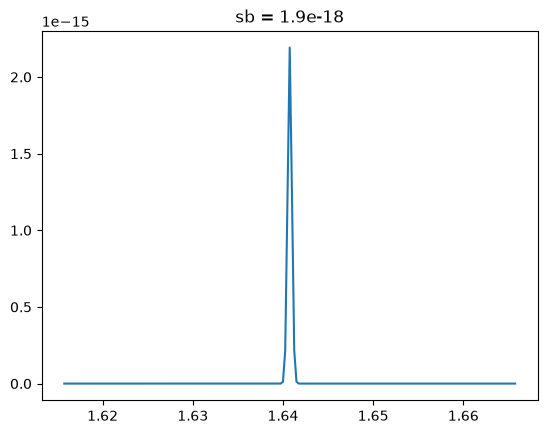

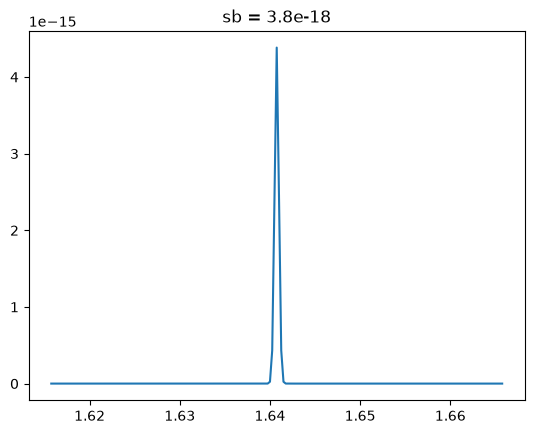

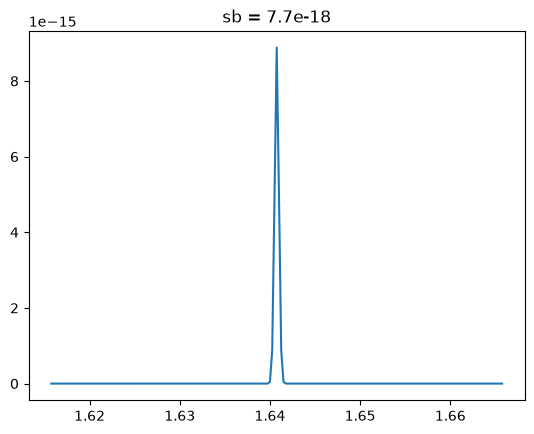

In [2]:
sb =  1.9e-18 #0.9e-18 #erg/cm^2/arcsec^2
z=1.5
centre_f_IFU =  6563 #5007 # angstrom!
centre_f_IFU *=1e-4 #micron :]
print(centre_f_IFU)
l_IFU = np.arange(centre_f_IFU-0.01, centre_f_IFU + 0.01, 1e-4)
print(centre_f_IFU)
fwhm_IFU = 100 #km/s

wvl_IFU_1, signal_IFU_1 = src.emission_line_signal(l_IFU, sb, fwhm_IFU, centre_f_IFU, z, instrument='IFU')

plt.plot(wvl_IFU_1, signal_IFU_1)
plt.title(f'sb = {sb}')
plt.show()

sb= 3.8e-18 #1.8e-18
wvl_IFU_2, signal_IFU_2 = src.emission_line_signal(l_IFU, sb, fwhm_IFU, centre_f_IFU, z, instrument='IFU')

plt.plot(wvl_IFU_2, signal_IFU_2)
plt.title(f'sb = {sb}')
plt.show()

sb = 7.7e-18 #3.7e-18
wvl_IFU_3, signal_IFU_3 = src.emission_line_signal(l_IFU, sb, fwhm_IFU, centre_f_IFU, z, instrument='IFU')

plt.plot(wvl_IFU_3, signal_IFU_3)
plt.title(f'sb = {sb}')
plt.show()

In [3]:
wvl_full_IFU_1, signal_full_IFU_1, thpt_IFU_1, sky_IFU_1, atm_IFU_1 = src.bin_signal_thp_atm_sky_data(wvl_IFU_1, signal_IFU_1, 
                                                                                                      wavelength_unit='micron')

wvl_full_IFU_2, signal_full_IFU_2, thpt_IFU_2, sky_IFU_2, atm_IFU_2 = src.bin_signal_thp_atm_sky_data(wvl_IFU_2, signal_IFU_2, 
                                                                                                      wavelength_unit='micron')
wvl_full_IFU_3, signal_full_IFU_3, thpt_IFU_3, sky_IFU_3, atm_IFU_3 = src.bin_signal_thp_atm_sky_data(wvl_IFU_3, signal_IFU_3, 
                                                                                                      wavelength_unit='micron')

In [4]:
signal_final_IFU_1 = src.apply_thpt_atm_to_signal(signal_full_IFU_1, thpt_IFU_1, atm_IFU_1)
signal_final_IFU_2 = src.apply_thpt_atm_to_signal(signal_full_IFU_2, thpt_IFU_2, atm_IFU_2)
signal_final_IFU_3 = src.apply_thpt_atm_to_signal(signal_full_IFU_3, thpt_IFU_3, atm_IFU_3)

sky_final_IFU_1 = src.apply_thpt_to_sky(sky_IFU_1, thpt_IFU_1)
sky_final_IFU_2 = src.apply_thpt_to_sky(sky_IFU_2, thpt_IFU_2)
sky_final_IFU_3 = src.apply_thpt_to_sky(sky_IFU_3, thpt_IFU_3)

area = 0.93 /4* np.pi*650**2

signal_per_pixel_IFU_1 = src.calculate_signal_to_photon_counts(wvl_full_IFU_1, signal_final_IFU_1, area)
signal_per_pixel_IFU_2 = src.calculate_signal_to_photon_counts(wvl_full_IFU_2, signal_final_IFU_2, area)
signal_per_pixel_IFU_3 = src.calculate_signal_to_photon_counts(wvl_full_IFU_3, signal_final_IFU_3, area)

sky_per_pixel_IFU_1 = src.calculate_sky_to_photon_counts(sky_final_IFU_1, area, angular_extent=0.8)
sky_per_pixel_IFU_2 = src.calculate_sky_to_photon_counts(sky_final_IFU_2, area, angular_extent=0.8)
sky_per_pixel_IFU_3 = src.calculate_sky_to_photon_counts(sky_final_IFU_3, area, angular_extent=0.8)

Invalid wavelength units. Assuming micron.
Invalid wavelength units. Assuming micron.
Invalid wavelength units. Assuming micron.


SNR per 1 exposure:  0.309695078210171
SNR per 1 exposure:  0.6165823674802359
SNR per 1 exposure:  1.2379505628369876
number of reads needed to reach targ SNR:  93.83695414296953
number of reads needed to reach targ SNR:  23.673382079165815
number of reads needed to reach targ SNR:  5.872674175244139
number of hours:  6.255796942864635
number of hours:  1.5782254719443876
number of hours:  0.3915116116829426


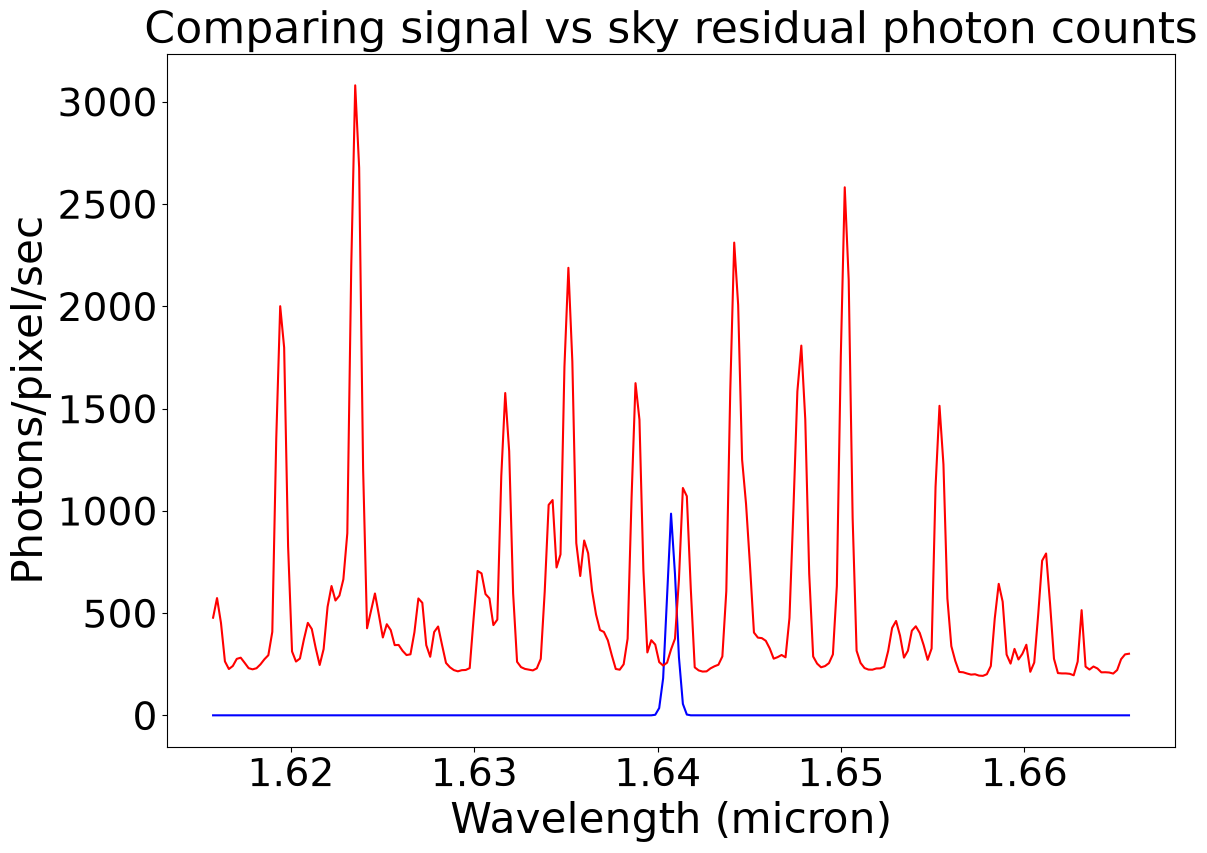

In [5]:
idx = 2

max_snr_per_exp_1 = src.calculate_max_snr(signal_per_pixel_IFU_1[idx], sky_per_pixel_IFU_1[idx])
max_snr_per_exp_2 = src.calculate_max_snr(signal_per_pixel_IFU_2[idx], sky_per_pixel_IFU_2[idx])
max_snr_per_exp_3 = src.calculate_max_snr(signal_per_pixel_IFU_3[idx], sky_per_pixel_IFU_3[idx])

targ_snr = 3.0

num_exp_1 = (targ_snr/max_snr_per_exp_1)**2
num_exp_2 = (targ_snr/max_snr_per_exp_2)**2
num_exp_3 = (targ_snr/max_snr_per_exp_3)**2

print('SNR per 1 exposure: ', max_snr_per_exp_1)
print('SNR per 1 exposure: ', max_snr_per_exp_2)
print('SNR per 1 exposure: ', max_snr_per_exp_3)

print('number of reads needed to reach targ SNR: ', num_exp_1)
print('number of reads needed to reach targ SNR: ', num_exp_2)
print('number of reads needed to reach targ SNR: ', num_exp_3)

print('number of hours: ', num_exp_1 * 240/3600)
print('number of hours: ', num_exp_2 * 240/3600)
print('number of hours: ', num_exp_3 * 240/3600)

snr_per_pix_IFU_1 = src.calculate_snr(signal_per_pixel_IFU_1[idx], sky_per_pixel_IFU_1[idx], num_exp=num_exp_1)
snr_per_pix_IFU_2 = src.calculate_snr(signal_per_pixel_IFU_2[idx], sky_per_pixel_IFU_2[idx], num_exp=num_exp_2)
snr_per_pix_IFU_3 = src.calculate_snr(signal_per_pixel_IFU_3[idx], sky_per_pixel_IFU_3[idx], num_exp=num_exp_3)

exp_time_1 = num_exp_1*240
exp_time_2 = num_exp_2*240
exp_time_3 = num_exp_3*240

plt.figure(figsize=(13,9))

plt.plot(wvl_full_IFU_1[idx], signal_per_pixel_IFU_1[idx]*exp_time_1, color = 'b')
plt.plot(wvl_full_IFU_1[idx], np.sqrt(sky_per_pixel_IFU_1[idx]*exp_time_1), color = 'r')

plt.ylabel("Photons/pixel/sec", fontsize = 30)
plt.xlabel("Wavelength (micron)", fontsize = 30)

plt.title("Comparing signal vs sky residual photon counts", fontsize = 32)

plt.tick_params('both', labelsize = 28)
plt.show()

# plt.plot(wvl_full_IFU_1[idx], snr_per_pix_IFU_1)
# plt.xlabel('Wavelength (micron)', fontsize = 30)
# plt.ylabel('SNR/pixel', fontsize = 30)
# plt.title('', fontsize = 32)
# plt.tick_params('both', labelsize = 28)
# plt.show()

# [OIII] case, redshift 2

0.5007
0.5007


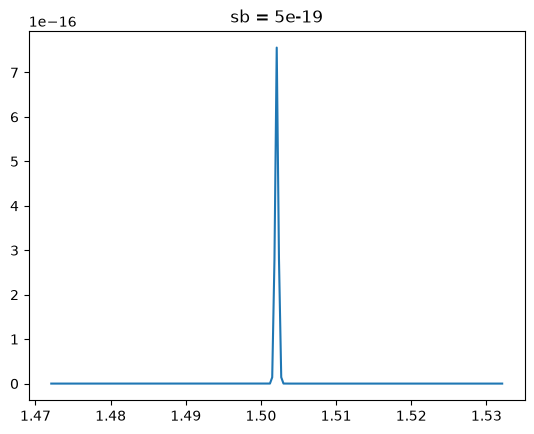

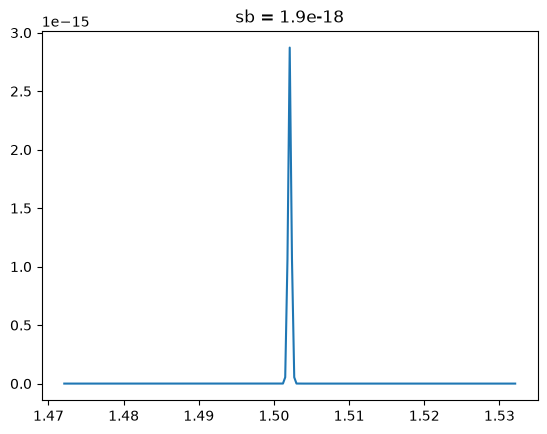

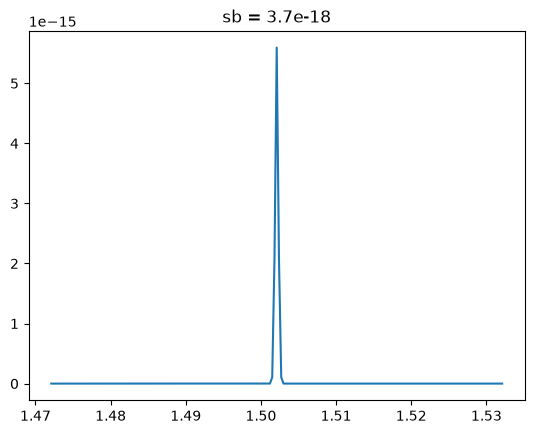

In [6]:
sb = 0.5e-18 #erg/cm^2/arcsec^2
z=2.0
centre_f_IFU =  5007 #5007 # angstrom!
centre_f_IFU *=1e-4 #micron :]
print(centre_f_IFU)
l_IFU = np.arange(centre_f_IFU-0.01, centre_f_IFU + 0.01, 1e-4)
print(centre_f_IFU)
fwhm_IFU = 100 #km/s

wvl_IFU_1, signal_IFU_1 = src.emission_line_signal(l_IFU, sb, fwhm_IFU, centre_f_IFU, z, instrument='IFU')

plt.plot(wvl_IFU_1, signal_IFU_1)
plt.title(f'sb = {sb}')
plt.show()

sb=1.9e-18
wvl_IFU_2, signal_IFU_2 = src.emission_line_signal(l_IFU, sb, fwhm_IFU, centre_f_IFU, z, instrument='IFU')

plt.plot(wvl_IFU_2, signal_IFU_2)
plt.title(f'sb = {sb}')
plt.show()

sb = 3.7e-18
wvl_IFU_3, signal_IFU_3 = src.emission_line_signal(l_IFU, sb, fwhm_IFU, centre_f_IFU, z, instrument='IFU')

plt.plot(wvl_IFU_3, signal_IFU_3)
plt.title(f'sb = {sb}')
plt.show()

In [7]:
wvl_full_IFU_1, signal_full_IFU_1, thpt_IFU_1, sky_IFU_1, atm_IFU_1 = src.bin_signal_thp_atm_sky_data(wvl_IFU_1, signal_IFU_1, 
                                                                                                      wavelength_unit='micron')

wvl_full_IFU_2, signal_full_IFU_2, thpt_IFU_2, sky_IFU_2, atm_IFU_2 = src.bin_signal_thp_atm_sky_data(wvl_IFU_2, signal_IFU_2, 
                                                                                                      wavelength_unit='micron')
wvl_full_IFU_3, signal_full_IFU_3, thpt_IFU_3, sky_IFU_3, atm_IFU_3 = src.bin_signal_thp_atm_sky_data(wvl_IFU_3, signal_IFU_3, 
                                                                                                      wavelength_unit='micron')

In [8]:
signal_final_IFU_1 = src.apply_thpt_atm_to_signal(signal_full_IFU_1, thpt_IFU_1, atm_IFU_1)
signal_final_IFU_2 = src.apply_thpt_atm_to_signal(signal_full_IFU_2, thpt_IFU_2, atm_IFU_2)
signal_final_IFU_3 = src.apply_thpt_atm_to_signal(signal_full_IFU_3, thpt_IFU_3, atm_IFU_3)

sky_final_IFU_1 = src.apply_thpt_to_sky(sky_IFU_1, thpt_IFU_1)
sky_final_IFU_2 = src.apply_thpt_to_sky(sky_IFU_2, thpt_IFU_2)
sky_final_IFU_3 = src.apply_thpt_to_sky(sky_IFU_3, thpt_IFU_3)

area = 0.93 /4* np.pi*650**2

signal_per_pixel_IFU_1 = src.calculate_signal_to_photon_counts(wvl_full_IFU_1, signal_final_IFU_1, area)
signal_per_pixel_IFU_2 = src.calculate_signal_to_photon_counts(wvl_full_IFU_2, signal_final_IFU_2, area)
signal_per_pixel_IFU_3 = src.calculate_signal_to_photon_counts(wvl_full_IFU_3, signal_final_IFU_3, area)

sky_per_pixel_IFU_1 = src.calculate_sky_to_photon_counts(sky_final_IFU_1, area, angular_extent=0.8)
sky_per_pixel_IFU_2 = src.calculate_sky_to_photon_counts(sky_final_IFU_2, area, angular_extent=0.8)
sky_per_pixel_IFU_3 = src.calculate_sky_to_photon_counts(sky_final_IFU_3, area, angular_extent=0.8)

Invalid wavelength units. Assuming micron.
Invalid wavelength units. Assuming micron.
Invalid wavelength units. Assuming micron.


In [9]:
idx = 2

max_snr_per_exp_1 = calculate_avg_snr(signal_per_pixel_IFU_1[idx], sky_per_pixel_IFU_1[idx])
max_snr_per_exp_2 = calculate_avg_snr(signal_per_pixel_IFU_2[idx], sky_per_pixel_IFU_2[idx])
max_snr_per_exp_3 = calculate_avg_snr(signal_per_pixel_IFU_3[idx], sky_per_pixel_IFU_3[idx])

targ_snr = 3.0

num_exp_1 = (targ_snr/max_snr_per_exp_1)**2
num_exp_2 = (targ_snr/max_snr_per_exp_2)**2
num_exp_3 = (targ_snr/max_snr_per_exp_3)**2

print('SNR per 1 exposure: ', max_snr_per_exp_1)
print('SNR per 1 exposure: ', max_snr_per_exp_2)
print('SNR per 1 exposure: ', max_snr_per_exp_3)

print('number of reads needed to reach targ SNR: ', num_exp_1)
print('number of reads needed to reach targ SNR: ', num_exp_2)
print('number of reads needed to reach targ SNR: ', num_exp_3)

print('number of hours: ', num_exp_1 * 240/3600)
print('number of hours: ', num_exp_2 * 240/3600)
print('number of hours: ', num_exp_3 * 240/3600)

snr_per_pix_IFU_1 = calculate_snr(signal_per_pixel_IFU_1[idx], sky_per_pixel_IFU_1[idx], num_exp=num_exp_1)
snr_per_pix_IFU_2 = calculate_snr(signal_per_pixel_IFU_2[idx], sky_per_pixel_IFU_2[idx], num_exp=num_exp_2)
snr_per_pix_IFU_3 = calculate_snr(signal_per_pixel_IFU_3[idx], sky_per_pixel_IFU_3[idx], num_exp=num_exp_3)

exp_time_1 = num_exp_1*240
exp_time_2 = num_exp_2*240
exp_time_3 = num_exp_3*240

plt.figure(figsize=(13,9))

plt.plot(wvl_full_IFU_1[idx], signal_per_pixel_IFU_1[idx]*exp_time_1, color = 'b')
plt.plot(wvl_full_IFU_1[idx], np.sqrt(sky_per_pixel_IFU_1[idx]*exp_time_1), color = 'r')

plt.ylabel("Photons/pixel/sec", fontsize = 30)
plt.xlabel("Wavelength (micron)", fontsize = 30)

plt.title("Comparing signal vs sky residual photon counts", fontsize = 32)

plt.tick_params('both', labelsize = 28)
plt.show()

NameError: name 'calculate_avg_snr' is not defined